In [59]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [60]:
#load csv
df = pd.read_csv("radiology/mri_case_level_stats.csv")
print(df.shape)

(95, 58)


In [61]:
#change case_id to string
df["case_id"] = df["case_id"].astype(str)

#define 10 positive and 10 negative cases
bcr_pos_ids = ['1041', '1090', '1100', '1122', '1130', '1137', '1169', '1208', '1219', '1258']
bcr_neg_ids = ['1036', '1060', '1129', '1140', '1179', '1186', '1205', '1264', '1284', '1303']
#create label column in csv for these cases
df["bcr_label"] = np.nan
df.loc[df["case_id"].isin(bcr_pos_ids), "bcr_label"] = 1
df.loc[df["case_id"].isin(bcr_neg_ids), "bcr_label"] = 0

print(df[["case_id", "bcr_label"]].head(20))
print(df["bcr_label"].value_counts(dropna=False))

   case_id  bcr_label
0     1003        NaN
1     1010        NaN
2     1011        NaN
3     1021        NaN
4     1025        NaN
5     1026        NaN
6     1028        NaN
7     1030        NaN
8     1031        NaN
9     1035        NaN
10    1036        0.0
11    1037        NaN
12    1039        NaN
13    1041        1.0
14    1048        NaN
15    1052        NaN
16    1056        NaN
17    1060        0.0
18    1062        NaN
19    1064        NaN
bcr_label
NaN    75
0.0    10
1.0    10
Name: count, dtype: int64


In [62]:
#drop all non mri columns (case_id, case_folder, and bcr_label)
X = df.drop(columns=["case_id", "case_folder", "bcr_label"], errors="ignore") #what goes into autoencoder
X = X.select_dtypes(include=[np.number])

#case_ids for matching back to patients and labels for plotting later
case_ids = df["case_id"].copy()
labels = df["bcr_label"].copy()

In [63]:
#scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#convert to pytorch tensors
X_tensor = torch.tensor(X_scaled, dtype = torch.float32)
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size = 16, shuffle = True)

In [64]:
#define 2D autoencoder
class Autoencoder2D(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

input_dim = X_tensor.shape[1]
model2D = Autoencoder2D(input_dim=input_dim, latent_dim=2)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model2D.parameters(), lr=1e-3)

In [65]:
#train autoencoder
num_epochs = 100

for epoch in range(num_epochs):
    model2D.train()
    total_loss = 0

    for batch in loader:
        x_batch = batch[0]

        optimizer.zero_grad()
        x_recon = model2D(x_batch)
        loss = criterion(x_recon, x_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    avg_loss = total_loss / len(loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 10/100, Loss: 0.8765
Epoch 20/100, Loss: 0.6684
Epoch 30/100, Loss: 0.5295
Epoch 40/100, Loss: 0.4853
Epoch 50/100, Loss: 0.4599
Epoch 60/100, Loss: 0.4401
Epoch 70/100, Loss: 0.4260
Epoch 80/100, Loss: 0.4112
Epoch 90/100, Loss: 0.4003
Epoch 100/100, Loss: 0.3847


In [66]:
#encode samples
model2D.eval()
with torch.no_grad():
    z = model2D.encoder(X_tensor).cpu().numpy()

In [76]:
#build latent dataframe
latent_df_2D = pd.DataFrame(z, columns=["z0", "z1"])
latent_df_2D["case_id"] = case_ids.values
latent_df_2D["bcr_label"] = labels.values

print(latent_df_2D.head())
print(latent_df_2D[["z0", "z1"]].describe())

          z0         z1 case_id  bcr_label
0  -4.883882  -5.899563    1003        NaN
1  10.148304 -14.114932    1010        NaN
2   5.261201  -2.840601    1011        NaN
3  -5.196034  -2.587315    1021        NaN
4   2.224293   0.531224    1025        NaN
              z0         z1
count  95.000000  95.000000
mean   -0.649502  -3.441530
std     4.688549   5.427050
min   -12.943358 -17.848936
25%    -3.446266  -5.491323
50%    -1.050213  -1.808165
75%     1.813447  -0.157275
max    10.691274   6.742468


In [68]:
#export encodings
encodings = latent_df_2D[["case_id", "z0", "z1"]]
encodings.to_csv("radiomics_latent_encodings_2D.csv", index = False)

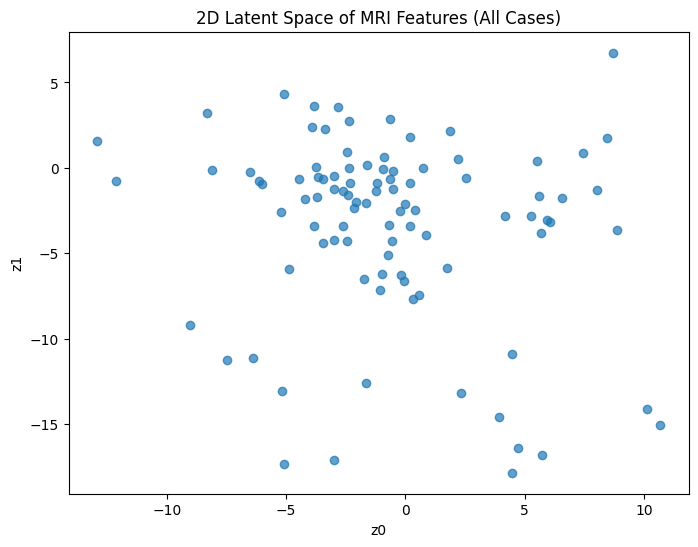

In [69]:
#plot all samples
plt.figure(figsize=(8, 6))
plt.scatter(latent_df_2D["z0"], latent_df_2D["z1"], alpha=0.7)
plt.xlabel("z0")
plt.ylabel("z1")
plt.title("2D Latent Space of MRI Features (All Cases)")
plt.show()

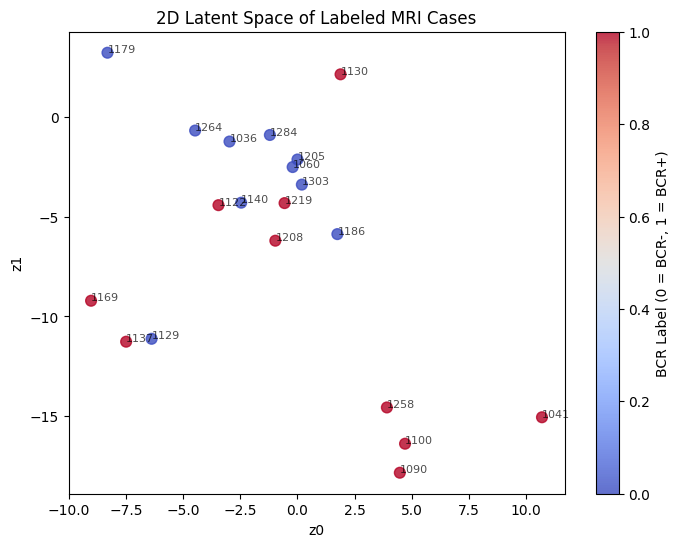

In [77]:
#plot only currently labeled samples (20 total, 10 of each)
labeled_df = latent_df_2D.dropna(subset=["bcr_label"]).copy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    labeled_df["z0"],
    labeled_df["z1"],
    c=labeled_df["bcr_label"],
    cmap="coolwarm",
    alpha=0.8,
    s=60
)
for _, row in labeled_df.iterrows():
    plt.text(row["z0"], row["z1"], row["case_id"], fontsize=8, alpha=0.7)

plt.xlabel("z0")
plt.ylabel("z1")
plt.title("2D Latent Space of Labeled MRI Cases")
cbar = plt.colorbar(scatter)
cbar.set_label("BCR Label (0 = BCR-, 1 = BCR+)")
plt.show()

In [71]:
#repeat for 8D
#define 8D autoencoder
class Autoencoder8D(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

input_dim = X_tensor.shape[1]
model8D = Autoencoder8D(input_dim=input_dim, latent_dim=8)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model8D.parameters(), lr=1e-3)

In [72]:
#train 8D autoencoder
num_epochs = 100

for epoch in range(num_epochs):
    model8D.train()
    total_loss = 0

    for batch in loader:
        x_batch = batch[0]

        optimizer.zero_grad()
        x_recon = model8D(x_batch)
        loss = criterion(x_recon, x_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    avg_loss = total_loss / len(loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 10/100, Loss: 0.8802
Epoch 20/100, Loss: 0.5448
Epoch 30/100, Loss: 0.4931
Epoch 40/100, Loss: 0.4198
Epoch 50/100, Loss: 0.3588
Epoch 60/100, Loss: 0.3225
Epoch 70/100, Loss: 0.2905
Epoch 80/100, Loss: 0.2592
Epoch 90/100, Loss: 0.2368
Epoch 100/100, Loss: 0.2190


In [73]:
#encode samples
model8D.eval()
with torch.no_grad():
    z8D = model8D.encoder(X_tensor).cpu().numpy()

In [74]:
latent_df_8D = pd.DataFrame(z8D, columns=[f"z{i}" for i in range(8)])
latent_df_8D["case_id"] = case_ids.values

latent_df_8D = latent_df_8D[["case_id"] + [f"z{i}" for i in range(8)]]

latent_df_8D.to_csv("radiomics_latent_encodings_8D.csv", index=False)

In [75]:
#create version of csvs with only 20 rows (10 positive and negative)
#cases
bcr_pos_ids = ['1041', '1090', '1100', '1122', '1130', '1137', '1169', '1208', '1219', '1258']
bcr_neg_ids = ['1036', '1060', '1129', '1140', '1179', '1186', '1205', '1264', '1284', '1303']
train_ids = bcr_pos_ids + bcr_neg_ids

#2D
train_latent_df_2D = latent_df_2D[latent_df_2D["case_id"].isin(train_ids)].copy()
train_latent_df_2D = train_latent_df_2D.sort_values("case_id")
train_latent_df_2D.to_csv("radiomics_latent_encodings_2D_train20.csv", index=False)

#8D
train_latent_df_8D = latent_df_8D[latent_df_8D["case_id"].isin(train_ids)].copy()
train_latent_df_8D = train_latent_df_8D.sort_values("case_id")
train_latent_df_8D.to_csv("radiomics_latent_encodings_8D_train20.csv", index = False)